# Physician Schedule Optimization with Probabilistic Modeling

**Portfolio project — prescriptive analytics for healthcare operations**

This project explores a practical scheduling question: **how many appointments should a physician accept when patient attendance is uncertain?** The objective is to move beyond a simple forecast of expected attendance and use probability to support an operational decision.

The notebook starts with the physician's daily capacity and an estimated show-up rate, then evaluates how different booking levels affect the probability of exceeding that capacity. The result is a simple decision framework that connects statistical modeling with a business trade-off between physician utilization, patient experience, and scheduling risk.


## Use case

Assume a physician can see **30 patients per day** and historical scheduling data indicate that approximately **25% of booked patients do not attend**, equivalent to a **75% show-up rate**. Empty appointment slots represent unused clinical capacity and lost revenue, while excessive overbooking can create longer waits, overtime, and a poor patient experience.

The business question is therefore not simply how many patients are expected to attend. It is: **how many appointments can be booked while keeping the probability of exceeding the physician's daily capacity within an acceptable level?**

### Modeling assumptions

For this analysis, each appointment is treated as an independent event with the same 75% probability of attendance. The physician's capacity is fixed at 30 completed appointments per day, and the historical no-show rate is assumed to remain stable. These assumptions keep the example focused on the decision logic; a production solution would test them against recent scheduling data and relevant patient or appointment segments.


### Step 1: Import the required libraries

`scipy.stats.binom` provides the binomial probability functions used in the analysis, while `matplotlib` is used to visualize the distribution of patient arrivals.


In [1]:
### import necessary libraries
import scipy
from scipy.stats import binom
import matplotlib.pyplot as plt


### Step 2: Estimate the booking level required to fill capacity on average

A first benchmark is obtained by dividing the physician's daily capacity by the expected show-up rate. With capacity for 30 patients and a 75% attendance rate, the calculation suggests **40 bookings**.

This is an **expected-value estimate**, not yet a scheduling recommendation. It tells us that 40 bookings would produce 30 arrivals on average, but individual days will vary around that average. The next steps quantify that variability.


In [2]:
workload = 30 # Max number of patients per day
prob = 0.75 # Percentage of patients that show up
x = workload / prob
print(f"The physician should book approximately {x:.0f} patients per day.")

The physician should book approximately 40 patients per day.


## From expected value to operational risk

The expected-value calculation is useful as a starting point, but it does not show how often the physician could face more patients than the schedule can accommodate. That uncertainty matters operationally: too few arrivals leave capacity unused, while too many arrivals can create waiting time, staff pressure, overtime, or rescheduling.

Because each booked patient is modeled as either attending or not attending, with a constant probability of 0.75, the number of patients who show up can be represented with a **binomial distribution**. For a given booking level, the distribution gives the probability of every possible number of arrivals.

This is the key shift from predictive to prescriptive thinking in the notebook: rather than using only the expected number of arrivals, the decision is evaluated against the probability of an operationally undesirable outcome.


### Step 3: Visualize the distribution of patient arrivals

The probability mass function (`binom.pmf`) is used to calculate the likelihood of each possible number of patients showing up when 40 appointments are booked. The chart makes the uncertainty around the expected value visible and shows why an average of 30 arrivals does not mean that exactly 30 patients will attend each day.


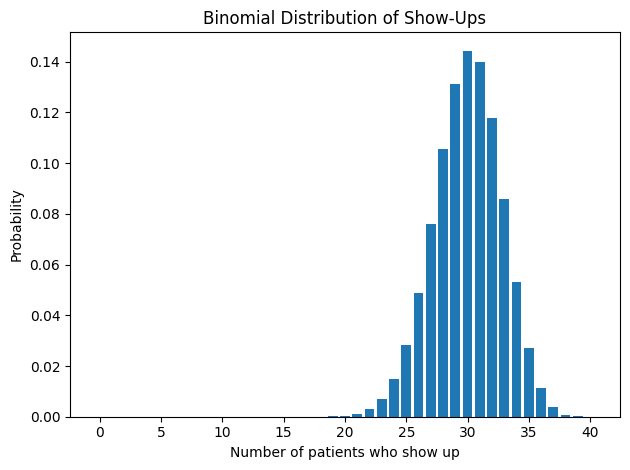

In [3]:
r_values = list(range(int(x) + 1))
dist = [binom.pmf(r, int(x), prob) for r in r_values]
# Plotting the graph
plots = plt.bar(r_values, dist)
xy = []
for plot in plots:
    xy.append(plot.get_xy())
plt.xlabel("Number of patients who show up")
plt.ylabel("Probability")
plt.title("Binomial Distribution of Show-Ups")
plt.tight_layout()
plt.show()

### Step 4: Quantify the risk of exceeding daily capacity

The cumulative distribution function (`binom.cdf`) is used to calculate the probability that **more than 30 patients** arrive when 40 appointments are booked.

With the current assumptions, the model returns an over-capacity probability of approximately **43.95%**. In practical terms, a booking policy based only on the expected value would leave the physician above capacity on roughly four out of every ten comparable days.

This result shows why capacity planning should consider the full probability distribution rather than relying on a single average.


In [4]:
linearPrediction = 40
overworked = 1 - binom.cdf(k = workload , n = linearPrediction, p = prob )
print("CDF",overworked)

CDF 0.439539731672533


### Step 5: Translate risk tolerance into a booking decision

A useful scheduling policy should reflect the organization's tolerance for over-capacity days. The final calculation uses the binomial percent point function (`binom.ppf`) to compare two example risk thresholds: **5%** and **10%**.

Under the logic implemented in this notebook, the corresponding booking levels are **34 appointments** for the more conservative threshold and **35 appointments** for the less conservative threshold. These values provide decision points that can be discussed with clinical and operations stakeholders rather than treating the mathematically expected 40 bookings as the default schedule.


In [5]:
target5 = 0.05
total5 = workload + binom.ppf(q = target5 ,n = workload ,p= 1 - prob,loc=0)
print("The total number of appointments the physician should book is given by", total5)
target10 = 0.10
total10 = workload + binom.ppf(q = target10 ,n = workload ,p= 1 - prob,loc=0)
print("The total number of appointments the physician should book is given by", total10)

The total number of appointments the physician should book is given by 34.0
The total number of appointments the physician should book is given by 35.0


## Conclusions

### Technical perspective

The analysis demonstrates how a simple binomial model can turn a historical no-show rate into a probability-based scheduling decision. The main technical lesson is that **expected attendance and capacity risk are different quantities**. Booking 40 patients produces an expected 30 arrivals, yet the model also shows a 43.95% probability of exceeding the 30-patient capacity. Incorporating the distribution of outcomes therefore provides a more useful basis for a scheduling policy.

The model is intentionally compact and should be treated as a baseline. A production version would validate the independence and constant-probability assumptions, estimate show-up probabilities from recent data, and consider segment-specific behavior such as day of week, appointment type, lead time, physician, seasonality, and patient history. It would also be valuable to compare predicted probabilities with observed attendance and recalibrate the model when behavior changes.

### Business perspective

The appropriate booking level depends on the cost of both sides of the trade-off. Empty slots reduce utilization and revenue, while over-capacity days can increase waiting time, overtime, rescheduling, and dissatisfaction. Based on the current notebook, **34 to 35 bookings per day** provide more conservative alternatives to the 40-booking expected-value benchmark, with the final choice depending on the organization's accepted level of operational risk.

A stronger business deployment would convert these outcomes into economic terms. For example, the scheduling team could assign a cost to an unused slot and a separate cost to an over-capacity arrival, then choose the booking level that minimizes expected total cost while respecting service-level constraints. That would extend this analysis from a probability-based rule into a measurable optimization policy.

### Portfolio takeaway

This use case shows a practical path from descriptive information (historical no-shows), to predictive modeling (the distribution of daily attendance), to prescriptive decision support (a booking policy linked to risk tolerance). The value of the model is not the complexity of the algorithm, but its ability to make an operational trade-off explicit, measurable, and actionable.
